# Random Forest Phase-Level Predictor (Energy)

Train a Random Forest classifier to predict phase level using the AMD Zen4c energy-labeled dataset only.

In [11]:
# !pip install scikit-learn joblib

import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import joblib

import matplotlib.pyplot as plt


=== Training AMDzen4c_energy ===
=== Tree Count Selection ===
   param_n_estimators  mean_test_score  std_test_score
0                  50         0.999698        0.000331
1                 100         0.999879        0.000148
2                 150         0.999819        0.000241
3                 200         0.999819        0.000241
4                 300         0.999819        0.000241
Best CV score: 0.999879
Selected n_estimators (smallest near-optimal): 50


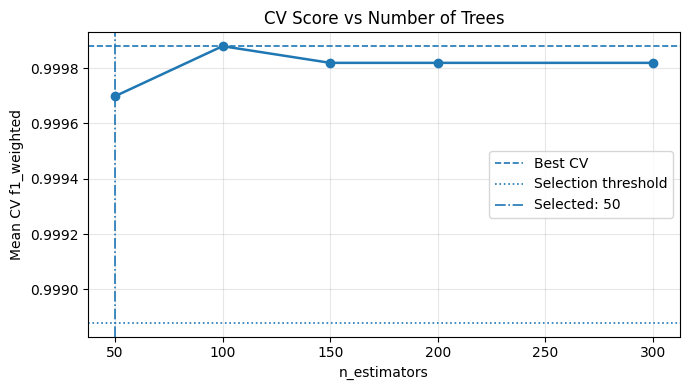

/mnt/REPACSS/home/li29729/Research2025/CPUfreq/PrimeMicroBenchmarks/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Params: {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10}
=== Classification Report ===
              precision    recall  f1-score   support

    HighFreq       1.00      1.00      1.00      2079
     LowFreq       1.00      1.00      1.00      1869
     MedFreq       1.00      1.00      1.00       195

    accuracy                           1.00      4143
   macro avg       1.00      1.00      1.00      4143
weighted avg       1.00      1.00      1.00      4143

=== Confusion Matrix ===
[[2079    0    0]
 [   0 1869    0]
 [   0    0  195]]
=== Feature Importances ===
            feature  importance
1   Compute_Density    0.343985
4  Vector_Intensity    0.215039
3       Branch_MPKI    0.202584
0               CPI    0.151177
2     Mem_Boundness    0.087215
Saved model to artifacts/rf_amdzen4c_energy.joblib


In [12]:
dataset = {
    "name": "AMDzen4c_energy",
    "csv_path": "../scripts/AMDzen4c/csv/training_dataset_dvfs_energy_labels_update.csv",
    "model_out": "artifacts/rf_amdzen4c_energy.joblib",
}

features = [
    "CPI",
    "Compute_Density",
    "Mem_Boundness",
    "Branch_MPKI",
    "Vector_Intensity",
]

artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(parents=True, exist_ok=True)

print(f"=== Training {dataset['name']} ===")
df = pd.read_csv(dataset["csv_path"])

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(subset=features + ["label"], inplace=True)

X = df[features]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 1: tune the number of trees only
base_params = {
    "max_depth": 12,
    "min_samples_split": 5,
    "min_samples_leaf": 2,
    "max_features": "sqrt",
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1,
}

rf_base = RandomForestClassifier(**base_params)

tree_grid = GridSearchCV(
    estimator=rf_base,
    param_grid={"n_estimators": [50, 100, 150, 200, 300]},
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1,
    return_train_score=False,
)
tree_grid.fit(X_train, y_train)

cv_df = pd.DataFrame(tree_grid.cv_results_)
cv_df = cv_df.sort_values(by="param_n_estimators")
best_score = cv_df["mean_test_score"].max()
score_tol = 0.001  # pick smallest tree count within 0.1% of best
near_opt = cv_df[cv_df["mean_test_score"] >= best_score - score_tol]
selected_n_estimators = int(near_opt.iloc[0]["param_n_estimators"])

print("=== Tree Count Selection ===")
print(cv_df[["param_n_estimators", "mean_test_score", "std_test_score"]])
print(f"Best CV score: {best_score:.6f}")
print(f"Selected n_estimators (smallest near-optimal): {selected_n_estimators}")

plt.figure(figsize=(7, 4))
plt.plot(cv_df["param_n_estimators"], cv_df["mean_test_score"], marker="o", linewidth=1.8)
plt.axhline(best_score, linestyle="--", linewidth=1.2, label="Best CV")
plt.axhline(best_score - score_tol, linestyle=":", linewidth=1.2, label="Selection threshold")
plt.axvline(selected_n_estimators, linestyle="-.", linewidth=1.2, label=f"Selected: {selected_n_estimators}")
plt.title("CV Score vs Number of Trees")
plt.xlabel("n_estimators")
plt.ylabel("Mean CV f1_weighted")
plt.grid(True, alpha=0.3)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

# Step 2: tune remaining RF hyperparameters at selected tree count
rf = RandomForestClassifier(
    n_estimators=selected_n_estimators,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
)

param_grid = {
    "max_depth": [None, 8, 12, 16],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1,
)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("Best Params:", grid.best_params_)
print("=== Classification Report ===")
print(classification_report(y_test, y_pred))
print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

importances = pd.DataFrame({
    "feature": features,
    "importance": best_model.feature_importances_,
}).sort_values(by="importance", ascending=False)
print("=== Feature Importances ===")
print(importances)

model_path = Path(dataset["model_out"])
joblib.dump({
    "model": best_model,
    "features": features,
    "classes": list(best_model.classes_),
    "best_params": grid.best_params_,
    "selected_n_estimators": selected_n_estimators,
    "tree_count_curve": cv_df[["param_n_estimators", "mean_test_score", "std_test_score"]].to_dict("records"),
    "dataset": dataset["name"],
}, model_path)
print(f"Saved model to {model_path}")


In [13]:
# Export trained RF model to C for DVFS controller
# Running this cell after training regenerates ../dvfs/model_amdzen4c_rf_energy.c

from pathlib import Path
import numpy as np

c_out = Path("../dvfs/model_amdzen4c_rf_energy_tmp.c")

# Label mapping must stay aligned with dvfs_config.h
label_to_enum = {
    "LowFreq": "FREQ_LEVEL_LOW",
    "MedFreq": "FREQ_LEVEL_MED",
    "HighFreq": "FREQ_LEVEL_HIGH",
}

rf_for_export = best_model
classes = list(rf_for_export.classes_)

# Keep feature names synchronized with training cell
export_features = features


def emit_tree_code(fh, estimator, tree_idx, feat_names):
    tree = estimator.tree_
    fh.write(
        f"static int tree_{tree_idx}(double CPI, double Compute_Density, double Mem_Boundness, double Stall_Ratio, double Branch_MPKI, double Vector_Intensity) {{\n"
    )

    def recurse(node, depth):
        indent = "    " * depth
        feat = tree.feature[node]
        if feat != -2:  # internal node
            feat_name = feat_names[feat]
            thr = tree.threshold[node]
            fh.write(f"{indent}if ({feat_name} <= {thr:.17g}) {{\n")
            recurse(tree.children_left[node], depth + 1)
            fh.write(f"{indent}}} else {{\n")
            recurse(tree.children_right[node], depth + 1)
            fh.write(f"{indent}}}\n")
        else:  # leaf
            class_idx = int(np.argmax(tree.value[node][0]))
            fh.write(f"{indent}return {class_idx};\n")

    recurse(0, 1)
    fh.write("}\n\n")


with c_out.open("w") as fh:
    fh.write("/* Auto-generated Random Forest model exporter */\n")
    fh.write("#include \"model.h\"\n\n")
    fh.write("/* Features used: CPI, Compute_Density, Mem_Boundness, Branch_MPKI, Vector_Intensity */\n")
    fh.write("/* Stall_Ratio is intentionally unused for this model. */\n\n")

    for idx, est in enumerate(rf_for_export.estimators_):
        emit_tree_code(fh, est, idx, export_features)

    fh.write("static FreqLevel class_to_freq(int class_idx) {\n")
    fh.write("    switch (class_idx) {\n")
    for i, cls in enumerate(classes):
        enum_val = label_to_enum.get(cls, "FREQ_LEVEL_HIGH")
        fh.write(f"        case {i}: return {enum_val};\n")
    fh.write("        default: return FREQ_LEVEL_HIGH;\n")
    fh.write("    }\n")
    fh.write("}\n\n")

    fh.write(
        "FreqLevel predict_phase_level(double CPI, double Compute_Density, double Mem_Boundness, double Stall_Ratio, double Branch_MPKI, double Vector_Intensity) {\n"
    )
    fh.write("    (void)Stall_Ratio;\n")
    fh.write(f"    int votes[{len(classes)}] = {{0}};\n")
    for idx in range(len(rf_for_export.estimators_)):
        fh.write(
            f"    votes[tree_{idx}(CPI, Compute_Density, Mem_Boundness, Stall_Ratio, Branch_MPKI, Vector_Intensity)]++;\n"
        )

    fh.write("\n    int best = 0;\n")
    fh.write(f"    for (int i = 1; i < {len(classes)}; ++i) {{\n")
    fh.write("        if (votes[i] > votes[best]) best = i;\n")
    fh.write("    }\n")
    fh.write("    return class_to_freq(best);\n")
    fh.write("}\n")

print(f"Exported RF C model to {c_out.resolve()}")


Exported RF C model to /mnt/REPACSS/home/li29729/Research2025/CPUfreq/PrimeMicroBenchmarks/dvfs/model_amdzen4c_rf_energy_tmp.c


In [14]:
# Example: load saved RF model and run one prediction
artifact = joblib.load("artifacts/rf_amdzen4c_energy.joblib")
rf_model = artifact["model"]
feature_order = artifact["features"]

print("Loaded classes:", artifact["classes"])
print("Feature order:", feature_order)

sample = pd.DataFrame([{
    "CPI": 1.0,
    "Compute_Density": 1.0,
    "Mem_Boundness": 1.0,
    "Branch_MPKI": 1.0,
    "Vector_Intensity": 1.0,
}])[feature_order]

pred = rf_model.predict(sample)[0]
print("Predicted phase level:", pred)


Loaded classes: ['HighFreq', 'LowFreq', 'MedFreq']
Feature order: ['CPI', 'Compute_Density', 'Mem_Boundness', 'Branch_MPKI', 'Vector_Intensity']
Predicted phase level: HighFreq
